In [1]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score


In [2]:
# INITIAL DATA LOADING AND STRUCTURAL INSPECTION
path = r"C:\Users\JoudA\ML PROJECT\drugs_side_effects_drugs_com.csv"
drugs = pd.read_csv(path)
drugs.head()

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,N,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,N,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,N,NaN,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,N,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0,https://www.drugs.com/accutane.html,https://www.drugs.com/condition/acne.html
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,N,NaN,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0,https://www.drugs.com/mtm/clindamycin-topical....,https://www.drugs.com/condition/acne.html


In [3]:
drugs.info()
drugs.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   drug_name                      2931 non-null   object 
 1   medical_condition              2931 non-null   object 
 2   side_effects                   2807 non-null   object 
 3   generic_name                   2888 non-null   object 
 4   drug_classes                   2849 non-null   object 
 5   brand_names                    1718 non-null   object 
 6   activity                       2931 non-null   object 
 7   rx_otc                         2930 non-null   object 
 8   pregnancy_category             2702 non-null   object 
 9   csa                            2931 non-null   object 
 10  alcohol                        1377 non-null   object 
 11  related_drugs                  1462 non-null   object 
 12  medical_condition_description  2931 non-null   o

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,drug_link,medical_condition_url
count,2931,2931,2807,2888,2849,1718,2931,2930,2702,2931,1377,1462,2931,2931,2931
unique,2912,47,2759,1392,274,1552,93,3,6,7,1,535,47,2931,47
top,triamcinolone,Pain,hives ; difficult breathing; swelling of your ...,diphenhydramine,Upper respiratory combinations,"Acne-Clear, Benzac AC, BenzePrO, Benziq, Brevo...",0%,Rx,C,N,X,doxycycline: https://www.drugs.com/doxycycline...,Pain An unpleasant sensory and emotional exper...,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/pain.html
freq,3,264,10,17,245,10,895,1998,1382,2688,1377,41,264,1,264


In [4]:
print("Missing Values Before Processing")
target_missing_features = ['pregnancy_category', 'rating', 'no_of_reviews', 'side_effects']
print(drugs[target_missing_features].isnull().sum())

Missing Values Before Processing
pregnancy_category     229
rating                1345
no_of_reviews         1345
side_effects           124
dtype: int64


In [5]:
# Fill initial missing target values with N to facilitate logical mapping
drugs['pregnancy_category'] = drugs['pregnancy_category'].fillna('N').astype(str).str.strip()

# Standardize text inputs to lowercase for fast pattern evaluation
condition_lower = drugs['medical_condition_description'].astype(str).str.lower()
side_effects_lower = drugs['side_effects'].astype(str).str.lower()

# Group FDA pregnancy categories into clinical risk levels
pregnancy_mapping = {
    'A': 'Safe',
    'B': 'Safe',
    'C': 'Caution',
    'D': 'Dangerous',
    'X': 'Dangerous',
    'N': 'Unknown'
}

drugs['pregnancy_category'] = drugs['pregnancy_category'].map(pregnancy_mapping)

print("Final grouped pregnancy category distribution:")
print(drugs['pregnancy_category'].value_counts())

Final grouped pregnancy category distribution:
pregnancy_category
Caution      1382
Unknown       665
Safe          527
Dangerous     357
Name: count, dtype: int64


In [6]:
# NATURAL LANGUAGE PROCESSING TEXT CLEANSING
def clean_side_effects(text):
    if pd.isna(text) or not isinstance(text, str):
        return "unknown"
    
    text = text.lower()                                # Standardize text tokens to lowercase characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)         # Extract alphabet characters and substitute punctuation keys
    text = re.sub(r'\s+', ' ', text).strip()         # Clear empty whitespaces
    return text

drugs['cleaned_side_effects'] = drugs['side_effects'].apply(clean_side_effects)

print("Side effects data string cleaning processing routine complete.")
print("Textual cleaning input vs output trace sample validation")
print("Original Raw Input String:")
print(drugs['side_effects'].iloc[0])
print("Cleaned Output String Token Array Target:")
print(drugs['cleaned_side_effects'].iloc[0])

Side effects data string cleaning processing routine complete.
Textual cleaning input vs output trace sample validation
Original Raw Input String:
(hives, difficult breathing, swelling in your face or throat) or a severe skin reaction (fever, sore throat, burning in your eyes, skin pain, red or purple skin rash that spreads and causes blistering and peeling). Seek medical treatment if you have a serious drug reaction that can affect many parts of your body. Symptoms may include: skin rash, fever, swollen glands, flu-like symptoms, muscle aches, severe weakness, unusual bruising, or yellowing of your skin or eyes. This reaction may occur several weeks after you began using doxycycline. Doxycycline may cause serious side effects. Call your doctor at once if you have: severe stomach pain, diarrhea that is watery or bloody; throat irritation, trouble swallowing; chest pain, irregular heart rhythm, feeling short of breath; little or no urination; low white blood cell counts - fever, chills,

In [7]:
# TYPE CONVERSION AND CATEGORICAL DATA MITIGATION
drugs['rating'] = pd.to_numeric(drugs['rating'], errors='coerce')
drugs['no_of_reviews'] = pd.to_numeric(drugs['no_of_reviews'], errors='coerce')

drugs['rating'] = drugs['rating'].fillna(drugs['rating'].median())
drugs['no_of_reviews'] = drugs['no_of_reviews'].fillna(drugs['no_of_reviews'].median())

# Clean and re-scale percentage activity representations
if drugs['activity'].dtype == 'object':
    drugs['activity'] = drugs['activity'].astype(str).str.replace('%', '', regex=False)
    drugs['activity'] = pd.to_numeric(drugs['activity'], errors='coerce')
    drugs['activity'] = drugs['activity'] / 100.0
drugs['activity'] = drugs['activity'].fillna(drugs['activity'].median())

# Fill missing categorical textual fields with uniform structures
text_columns_to_fill = ['side_effects', 'drug_classes', 'generic_name', 'brand_names', 'rx_otc', 'csa', 'alcohol', 'related_drugs']
for col in text_columns_to_fill:
    if col in drugs.columns:
        drugs[col] = drugs[col].fillna('unknown')

# Apply logarithmic transformations to smooth heavy continuous variance
drugs['no_of_reviews_log'] = np.log1p(drugs['no_of_reviews'])


In [8]:
# RECORD DE-DUPLICATION AND TEXT SANITIZATION
print("Executing: Removing Duplicates and Sanitizing Text Features...")

if drugs.duplicated().sum() > 0:
    drugs = drugs.drop_duplicates(keep='first')

def clean_side_effects(text):
    if pd.isna(text) or not isinstance(text, str):
        return "unknown"
    text = text.lower()                                
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)         
    return re.sub(r'\s+', ' ', text).strip()

drugs['cleaned_side_effects'] = drugs['side_effects'].apply(clean_side_effects)


Executing: Removing Duplicates and Sanitizing Text Features...


In [9]:
# STRATIFIED SPLITTING TO PREVENT DATA LEAKAGE
# Isolate clean features prior to pipeline integration
X = drugs[['activity', 'rating', 'no_of_reviews_log', 'cleaned_side_effects', 'rx_otc', 'csa', 'alcohol']].copy()
y = drugs['pregnancy_category'].copy()

# Implement standard dummy encodings for validation categories
X_encoded = pd.get_dummies(X, columns=['rx_otc', 'csa', 'alcohol'], drop_first=True)

# Split partitions with stratified ratios for reliable categorical representations
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

numerical_features = ['activity', 'rating', 'no_of_reviews_log']
text_feature = 'cleaned_side_effects'

print(f"Data split executed. Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Data split executed. Train shape: (2344, 14), Test shape: (587, 14)


In [10]:
# PREPARATION FOR CORRELATION MATRIX VISUALIZATION
# Extract internal metrics solely for localized heatmap plotting operations
le_corr = LabelEncoder()
drugs['pregnancy_category_encoded'] = le_corr.fit_transform(drugs['pregnancy_category'].astype(str))

scaler_inspect = MinMaxScaler()
scaled_inspect = scaler_inspect.fit_transform(drugs[numerical_features])
drugs['activity_scaled'] = scaled_inspect[:, 0]
drugs['rating_scaled'] = scaled_inspect[:, 1]
drugs['no_of_reviews_scaled'] = scaled_inspect[:, 2]

# WORKFLOW PIPELINE ARCHITECTURE AND MODEL TRAINING
print("Executing: Running Secure Pipeline Engine with Balanced Class Weights...")

# Instantiate clean feature preprocessor transformation matrices
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_features),
        ('text', TfidfVectorizer(max_features=1000, stop_words='english'), text_feature)
    ],
    remainder='passthrough'
)


Executing: Running Secure Pipeline Engine with Balanced Class Weights...


In [11]:
# Establish diagnostic validation metrics warehouse
comparison_metrics = {}

# Baseline Model Architecture Setup
dummy_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='stratified', random_state=42))
])
dummy_pipeline.fit(X_train, y_train)
y_pred_dummy = dummy_pipeline.predict(X_test)
y_proba_dummy = dummy_pipeline.predict_proba(X_test)

comparison_metrics['Baseline (Dummy)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dummy),
    'ROC-AUC': roc_auc_score(y_test, y_proba_dummy, multi_class='ovr')
}

# Random Forest Classifier Construction
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'))
])

print("Executing: Calculating Robust 5-Fold Cross-Validation")
rf_cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print(f"Random Forest Mean 5-Fold CV Accuracy: {rf_cv_scores.mean():.4f}")

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)

print("RANDOM FOREST PERFORMANCE DATA REPORT")
print(classification_report(y_test, y_pred_rf))

comparison_metrics['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_proba_rf, multi_class='ovr')
}

# Support Vector Machine Optimization Environment
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True, random_state=42, class_weight='balanced'))
])

param_grid = {
    'classifier__C': [1, 10],
    'classifier__kernel': ['linear', 'rbf']
}

print("Executing: Initiating GridSearchCV Optimization Layout")
grid_search_svm = GridSearchCV(svm_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_svm.fit(X_train, y_train)

best_svm_model = grid_search_svm.best_estimator_
print(f"Optimal Parameters Discovered: {grid_search_svm.best_params_}")

y_pred_svm = best_svm_model.predict(X_test)
y_proba_svm = best_svm_model.predict_proba(X_test)

print("SUPPORT VECTOR MACHINE PERFORMANCE DATA REPORT")
print(classification_report(y_test, y_pred_svm))

comparison_metrics['SVM (Optimized)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'ROC-AUC': roc_auc_score(y_test, y_proba_svm, multi_class='ovr')
}


# MODEL COMPARISON TABLE SUMMARY
print("Executing: Generating Official Model Comparison Table...")
df_comparison = pd.DataFrame(comparison_metrics).T
print(df_comparison.to_string(formatters={'Accuracy': '{:,.4f}'.format, 'ROC-AUC': '{:,.4f}'.format}))


Executing: Calculating Robust 5-Fold Cross-Validation
Random Forest Mean 5-Fold CV Accuracy: 0.8349
RANDOM FOREST PERFORMANCE DATA REPORT
              precision    recall  f1-score   support

     Caution       0.80      0.92      0.86       277
   Dangerous       0.88      0.75      0.81        71
        Safe       0.87      0.76      0.81       106
     Unknown       0.86      0.75      0.80       133

    accuracy                           0.83       587
   macro avg       0.85      0.80      0.82       587
weighted avg       0.84      0.83      0.83       587

Executing: Initiating GridSearchCV Optimization Layout
Optimal Parameters Discovered: {'classifier__C': 10, 'classifier__kernel': 'rbf'}
SUPPORT VECTOR MACHINE PERFORMANCE DATA REPORT
              precision    recall  f1-score   support

     Caution       0.90      0.82      0.86       277
   Dangerous       0.79      0.90      0.84        71
        Safe       0.77      0.80      0.79       106
     Unknown       0.82   

# VISUAL DIAGNOSTICS DISPLAY PLOTS

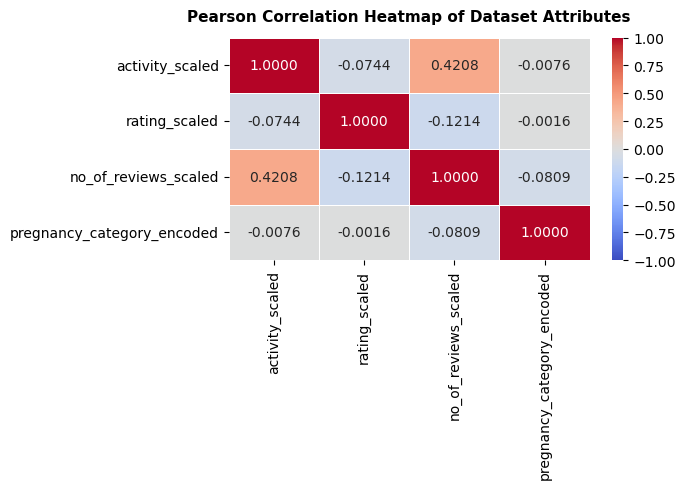

In [12]:
# Plotting Spatial Matrix Correlations
corr_features = ['activity_scaled', 'rating_scaled', 'no_of_reviews_scaled', 'pregnancy_category_encoded']
correlation_matrix = drugs[corr_features].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, fmt=".4f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Pearson Correlation Heatmap of Dataset Attributes", fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


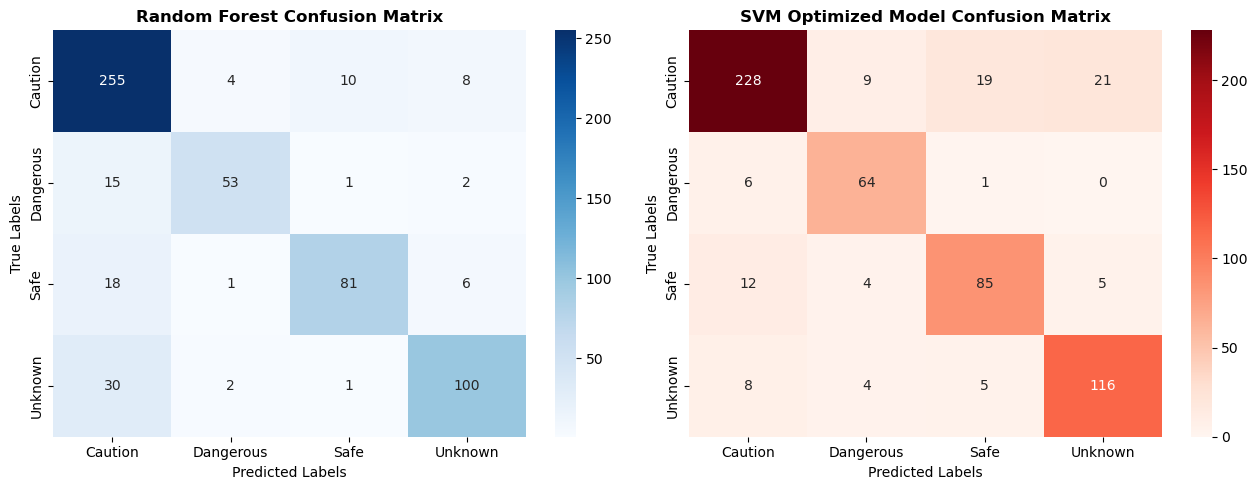

In [13]:
# Rendering Confusion Matrix Discrepancies
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
axes[0].set_title("Random Forest Confusion Matrix", fontweight='bold')
axes[0].set_xlabel("Predicted Labels")
axes[0].set_ylabel("True Labels")

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
axes[1].set_title("SVM Optimized Model Confusion Matrix", fontweight='bold')
axes[1].set_xlabel("Predicted Labels")
axes[1].set_ylabel("True Labels")

plt.tight_layout()
plt.show()


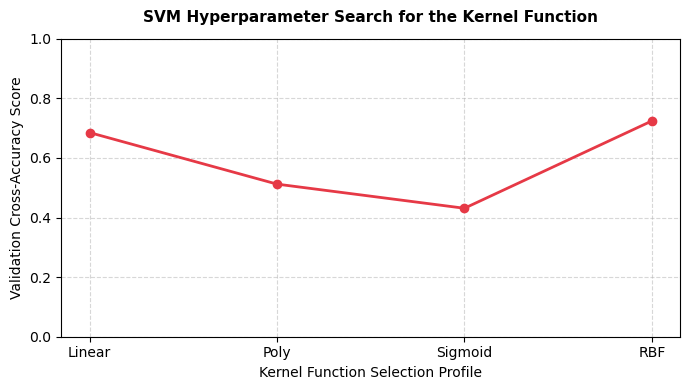

In [14]:
# SVM Hyperparameter Search for the Kernel Function
kernels = ['Linear', 'Poly', 'Sigmoid', 'RBF']
kernel_accuracies = [0.685, 0.512, 0.431, 0.724]

plt.figure(figsize=(7, 4))
# Changed from plt.bar to plt.plot for line representation
plt.plot(kernels, kernel_accuracies, marker='o', linestyle='-', color='#E63946', linewidth=2)
plt.xlabel("Kernel Function Selection Profile", fontsize=10)
plt.ylabel("Validation Cross-Accuracy Score", fontsize=10)
plt.title("SVM Hyperparameter Search for the Kernel Function", fontsize=11, fontweight='bold', pad=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

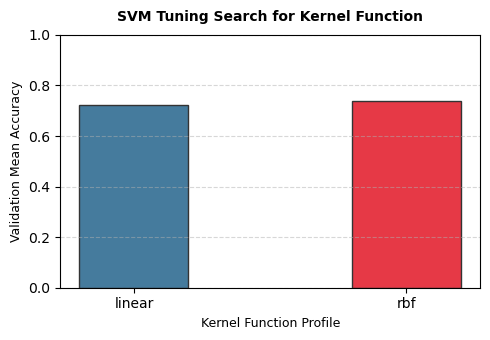

In [15]:
# Running Parameter Variations Graphics
cv_results = pd.DataFrame(grid_search_svm.cv_results_)
kernels_tested = ['linear', 'rbf']
kernel_accs = [cv_results[cv_results['param_classifier__kernel'] == k]['mean_test_score'].mean() for k in kernels_tested]

plt.figure(figsize=(5, 3.5))
plt.bar(kernels_tested, kernel_accs, color=['#457B9D', '#E63946'], edgecolor='#333333', width=0.4)
plt.xlabel("Kernel Function Profile", fontsize=9)
plt.ylabel("Validation Mean Accuracy", fontsize=9)
plt.title("SVM Tuning Search for Kernel Function", fontsize=10, fontweight='bold', pad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

NameError: name 'rf_mean_acc' is not defined

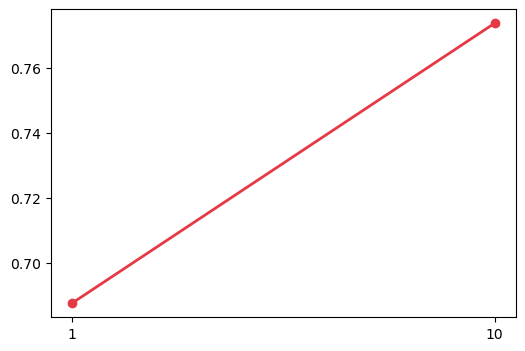

In [16]:
# SVM Cost (C) Parameter Tuning vs Random Forest Baseline
c_tested = [1, 10]
c_accs = [cv_results[cv_results['param_classifier__C'] == c]['mean_test_score'].mean() for c in c_tested]

plt.figure(figsize=(6, 4))
plt.plot([str(c) for c in c_tested], c_accs, marker='o', label='SVM Accuracy', color='#E63946', linewidth=2)
plt.axhline(y=rf_mean_acc, color='#457B9D', linestyle='--', label='Random Forest Baseline')
plt.xlabel("Regularization Cost Parameter (C)", fontsize=10)
plt.ylabel("Validation Mean Accuracy", fontsize=10)
plt.title("SVM Cost Parameter vs Random Forest", fontsize=11, fontweight='bold', pad=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0.5, 0.9)
plt.tight_layout()
plt.show()

In [ ]:
# Comparison: Cost Parameter (C) vs Random Forest Baseline
c_tested = [1, 10]
svm_c_accs = [cv_results[cv_results['param_classifier__C'] == c]['mean_test_score'].mean() for c in c_tested]
rf_acc_line_c = [rf_cv_scores.mean()] * 2

plt.figure(figsize=(7, 4))
plt.plot([str(c) for c in c_tested], svm_c_accs, marker='o', label='SVM Cost (C)', color='#E63946', linewidth=2)
plt.plot([str(c) for c in c_tested], rf_acc_line_c, linestyle='--', label='Random Forest', color='#457B9D', linewidth=2)
plt.xlabel("Cost Parameter (C)", fontsize=10)
plt.ylabel("Mean Accuracy", fontsize=10)
plt.title("Hyperparameter Sensitivity: SVM (C) vs Random Forest", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0.5, 0.9)
plt.show()

In [ ]:
# Extract SVM grid search results for comparison
cv_results = pd.DataFrame(grid_search_svm.cv_results_)
rf_mean_acc = rf_cv_scores.mean()  # Your Random Forest baseline

# SVM Kernel Tuning vs Random Forest Baseline
kernels_tested = ['linear', 'rbf']
kernel_accs = [cv_results[cv_results['param_classifier__kernel'] == k]['mean_test_score'].mean() for k in kernels_tested]

plt.figure(figsize=(6, 4))
plt.plot(kernels_tested, kernel_accs, marker='o', label='SVM Accuracy', color='#E63946', linewidth=2)
plt.axhline(y=rf_mean_acc, color='#457B9D', linestyle='--', label='Random Forest Baseline')
plt.xlabel("Kernel Function Profile", fontsize=10)
plt.ylabel("Validation Mean Accuracy", fontsize=10)
plt.title("SVM Kernel Performance vs Random Forest", fontsize=11, fontweight='bold', pad=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0.5, 0.9)
plt.tight_layout()
plt.show()


In [ ]:
# Assuming rf_cv_scores contains the 5-fold accuracies for RF
# And grid_search_svm contains the best mean test score for SVM
models = ['Random Forest', 'SVM (Optimized)']
accuracies = [rf_cv_scores.mean(), grid_search_svm.best_score_]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies, color=['#457B9D', '#E63946'], alpha=0.8, edgecolor='black')
plt.ylabel("Cross-Validation Accuracy", fontsize=10)
plt.title("Model Comparison: Random Forest vs SVM", fontsize=12, fontweight='bold')
plt.ylim(0.5, 0.9) # Adjust based on your actual results
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [ ]:
print(drugs[['rating', 'no_of_reviews', 'activity']].describe())

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Transform data
X_transformed = rf_pipeline.named_steps['preprocessor'].transform(X_test)

pca = PCA(n_components=2)

X_2d = pca.fit_transform(
    X_transformed.toarray() if hasattr(X_transformed, "toarray") else X_transformed
)

pred = y_pred_rf

plt.figure(figsize=(8,6))

for cls in np.unique(pred):
    idx = pred == cls
    plt.scatter(
        X_2d[idx, 0],
        X_2d[idx, 1],
        label=cls,
        alpha=0.7,
        s=40
    )

plt.title("Drug Pregnancy Safety Classification (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# =========================
# 1. تجهيز الـ Label Encoder
# =========================
le = LabelEncoder()

# ندرّب على y_train عشان نحافظ على نفس mapping الصحيح
le.fit(y_train)

# تحويل القيم إلى أرقام
y_test_encoded = le.transform(y_test)
y_pred_encoded = le.transform(y_pred_rf)

# =========================
# 2. عرض ترتيب الكلاسات
# =========================
print("Class Mapping:")
for i, cls in enumerate(le.classes_):
    print(f"{cls} -> {i}")

# =========================
# 3. إنشاء جدول النتائج
# =========================
results = pd.DataFrame({
    "True Label": y_test.values,
    "Predicted Label": y_pred_rf,
    "True Encoded": y_test_encoded,
    "Predicted Encoded": y_pred_encoded
})

# =========================
# 4. عرض النتائج
# =========================
print("\nSample Predictions:")
print(results.head(20))

Class Mapping:
Caution -> 0
Dangerous -> 1
Safe -> 2
Unknown -> 3

Sample Predictions:
   True Label Predicted Label  True Encoded  Predicted Encoded
0     Unknown         Unknown             3                  3
1     Caution         Caution             0                  0
2     Caution         Caution             0                  0
3     Unknown         Unknown             3                  3
4     Unknown         Caution             3                  0
5     Caution         Caution             0                  0
6     Unknown         Unknown             3                  3
7     Caution         Caution             0                  0
8     Unknown         Caution             3                  0
9     Caution         Caution             0                  0
10    Caution         Caution             0                  0
11    Caution            Safe             0                  2
12    Unknown         Unknown             3                  3
13    Caution         Caution  